<img src="./imagenes/logo_UTN.svg" align="right" width="200"/>

# **Teoría de Circuitos II**
## Trabajo Semanal 3

---
**Profesor:** Mariano Llamedo Soria \
**Ayudante de TPs:** David Moharos \
**Jefe de TPs:** César Fuoco

**Alumno:** Valentin Dorrego\
**Curso:** R4052\
**Ciclo lectivo:** 2026  

---

### A partir de la siguiente plantilla de requerimientos:
| Plantilla de Requerimientos | Parámetros del Filtro |
| :---: | :--- |
| <img src="imagenes/3/plantilla.png" width="500"> | <br>• $\alpha_{\text{Max}}$: 0.5 dB<br>• $\alpha_{\text{mín}}$: 30 dB<br>• $f_p$: 40 kHz<br>• $f_s$: 10 kHz |

1. Obtener la transferencia mediante aproximación de Chebyshev del filtro requerido.

2. Obtener la respuesta en frecuencia (módulo y fase) de forma cualitativa. Compare además el pzmap con el del filtro pasabajo prototipo.

3. Implementar el circuito **normalizado** con estructuras pasivas utilizando dispositivos activos para separar secciones.

4. Reemplace los inductores en las estructuras pasivas mediante el *GIC de Antoniou*, en la configuración que considere más apropiada.

5. Reemplace la SOS pasiva del punto 3. por la estructura MFB en configuración pasa altos y realice el estudio de sensibilidad de $S_{\omega_0}^{C_1}$, $S_Q^{R_1}$ y $S_Q^{R_2}$.

6. En todos los casos, verifique el requerimiento de la plantilla en LTSpice mediante el uso de cursores.

**Bonus:**

* +10 🤯 ¿Podría implementar una red del mismo orden con una aproximación de máxima planicidad?
* +10 💎 Verifique que el orden obtenido analíticamente, mediante **simulación numérica** en Python, cumple con el requerimiento de la plantilla.
* +10 🍺 Presentación en Jupyter Notebook.

---

## Resolucion:
1) Obtenemos la transferencia mediante la aproximacion de Chebychev, como podemos observar el filtro es del tipo Pasaaltos.
    Lo primero que hacemos es normalizar la plantilla, en donde nos termina quedando $\omega_p = 4$ y $\omega_s = 1/4$.
    Como nuestro objetivo es realizar una **transformacion en frecuencia**, para poder trabajar el filtro Pasaaltos como un filtro pasabajos prototipo.     Por lo tanto obtenemos la plantilla equivalente del filtro pasabajos prototipo, en donde nos queda:
   | Plantilla de Requerimientos | Parámetros del Filtro |
| :---: | :--- |
| <img src="imagenes/3/plantilla_lp.png" width="500"> | <br>• $\alpha_{\text{Max}}$: 0.5 dB<br>• $\alpha_{\text{mín}}$: 30 dB<br>• $\omega_p$: 1/4<br>• $\omega_s$: 1 |

    Una vez obtenida la plantilla equivalente del filtro, comenzamos a obtener los parametros de nuestro filtro pasabajos prototipo de Chebychev.
    $$
    \begin{aligned}
    |T(j\omega)|^2=\frac{1}{1+\xi^2 \cdot C_n^{2}(\omega)}
    \end{aligned}
    $$

    Determinamos el orden del filtro
    $$
    \begin{align}
    \xi^2 &= 10^{\frac{\alpha_{max}}{10}} = 0.122
    \end{align}
    $$
   
    $$
    \begin{align}
    \alpha_n &= 10\cdot \log\left(1+\xi^2\cdot \cosh^2(n\cdot \cosh^{-1}(\omega_s))\right)
    \end{align}
    $$
   Iterando $n$ hasta que $\alpha_n > \alpha_{min}$ obtenemos que le filtro será un filtro de orde $n=3$.

   Dado que tenemos un filtro Chebyshev, debmos calcular las raices del denominador.
   Las funciones armonica de Chebyshevpuede ser expresadas por equivalentes polinomis que siguen una fomra recursiva de serie:
    $$
    \begin{align}
    C_n(\omega) = 2 \cdot C_{n-1}(\omega) - C_{n-2}(\omega) \quad \text{con} \quad C_0(\omega)=1 \quad \text{y} \quad C_1(\omega)=\omega 
    \end{align}
    $$
   Entonces para $n = 2%$ tenemos
    $$
   \begin{align}
    C_2(\omega) = 2 \cdot C_1(\omega) - C_0(\omega) = 2\cdot\omega^2-1  
    \end{align}
    $$
   Y para $n = 3%$ tenemos
    $$
   \begin{align}
    C_3(\omega) = 2 \cdot \omega C_2(\omega) - C_1(\omega) = 2\cdot\omega(2\cdot\omega^2-1)-\omega = 4\cdot\omega^3 - 2\cdot\omega -\omega = 4\cdot\omega^3-3\omega  
    \end{align}
    $$

   Entonces reenplazando nos queda:
    $$
    \begin{aligned}
    |T(j\omega)|^2=\frac{1}{1+\xi^2 \cdot C_n^{2}(\omega)} =\frac{1}{1+\xi^2 \cdot (4\cdot\omega^{3}-3\omega)}=\frac{\frac{1}{16\cdot\xi^{2}}}{-s^6-s^4\cdot\frac{3}{2}-s^2\cdot\frac{9}{16}+\frac{1}{16\cdot\xi^2}}
    \end{aligned}
    $$
    Como sabemos que $2N=6$, entonces $|H(s)|$ tiene un denominador cuyo polinomio es de grado 3 y $H(-s)$ tambien.
    $$
    \begin{aligned}
    |H(s)|\cdot|H(-s)|= \frac{1}{(s^3+a\cdot s^2+b\cdot s+c)\cdot(-s^3+a\cdot s^2-b\cdot s+c)}
    \end{aligned}
    $$
    Trabajando un poco algebraicamente llegamos a
    $$
    \begin{aligned}
    \frac{\frac{1}{16\cdot\xi^{2}}}{-s^6-s^4\cdot\frac{3}{2}-s^2\cdot\frac{9}{16}+\frac{1}{16\cdot\xi^2}} = \frac{1}{(-s^6+0\cdot^5+(a^2-2b)\cdot s^4+(0)\cdot s^3+(2ac-b^2)\cdot s^2+c^2)}
    \end{aligned}
    $$
    Igualando termino a termino obtenemos
       $$
    \begin{aligned}
    a=1,25\\
    b=1,53\\
    c=1,25
    \end{aligned}
    $$
   Entonces terminamos obteniendo nuestra funcion transferencia Pasabajos prototipo
    $$
    \begin{aligned}
    H_{lp}(s)=\frac{0.715}{s^3+1,25\cdot s^2+1,53\cdot s+0,715}
    \end{aligned}
    $$
   Transformo el circuito a un pasa altos, $k(s)=\frac{1}{s}$
       $$
    \begin{aligned}
    H_{hp}(s)=\frac{0.715}{s^{-3}+s^{-2}\cdot1,25+s^{-1}\cdot 1,53+0,715}=\frac{0.715 \cdot s^3}{ s^3\cdot0,715+s^2\cdot1,53 +1,25\cdot s+1}
    \end{aligned}
    $$
   Quedandonos finalmente la transferencia del pasa altos.
    $$
    \boxed{
    \begin{aligned}
    H_{hp}(s)=\frac{s^3}{s^{3}+2,14\cdot s^2+ 1,75\cdot s^1+1,4}
    \end{aligned}
    }
    $$

2) La respuesta de modulo y fase de forma cualitativa se encuentra resuelto en el anexo de calculos, basicamente teniendo en cuenta que tenemos un filtro Pasaaltos Chebychev de orden 3 con ganancia de 0db en la banda de paso y teniendo tres polos en el origen.
   Ademas tenemos que tener en cuenta que para el diagrama de polos y ceros, en el caso del pasabajos prototipo tendremos tres polos en el semiplano izquierdo, pero no tienen el mismo modulo, por ende se encuentran sobre una elipse, entonces cuando realizamos la transformacion en frecuencia no se espejan los polos, a comparacion de otros tipos de filtros vistos en clase como el Butterworth en donde se encuentran sobre un circulo con modulo unitario.
   
* A continuacion visualizamos los graficos en python.

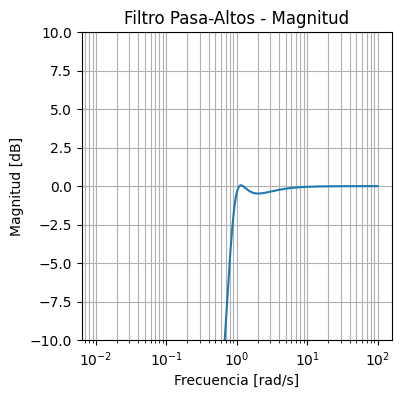

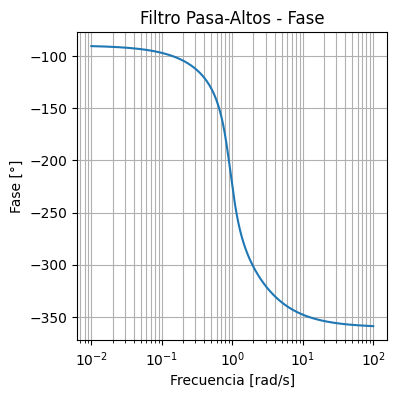

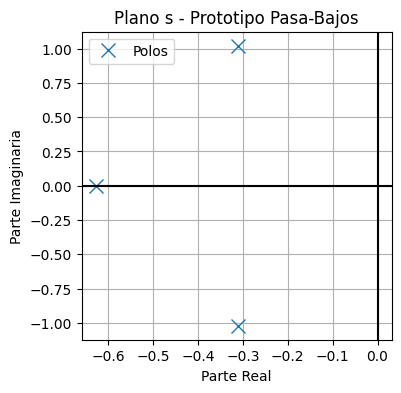

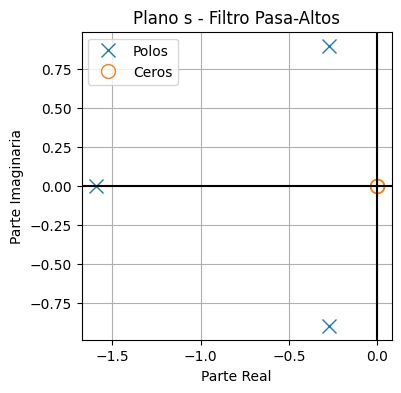

In [1]:
# -*- coding: utf-8 -*-

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

num_lp = [0.715]
den_lp = [1, 1.25, 1.53, 0.715]

num_hp = [1, 0, 0, 0]
den_hp = [1, 2.14, 1.75, 1.4]

hp = signal.TransferFunction(num_hp, den_hp)

w = np.logspace(-2, 2, 1000)

w, mag, phase = signal.bode(hp, w)

# ---------------------------------------------------------
# MODULO
# ---------------------------------------------------------

plt.figure(figsize=(4,4))

plt.semilogx(w, mag)

plt.title('Filtro Pasa-Altos - Magnitud')
plt.xlabel('Frecuencia [rad/s]')
plt.ylabel('Magnitud [dB]')
plt.ylim(-10,10)
plt.grid(True, which='both')

# ---------------------------------------------------------
# FASE
# ---------------------------------------------------------

plt.figure(figsize=(4,4))

plt.semilogx(w, phase)

plt.title('Filtro Pasa-Altos - Fase')
plt.xlabel('Frecuencia [rad/s]')
plt.ylabel('Fase [°]')

plt.grid(True, which='both')

# =========================================================
# POLOS Y CEROS LP
# =========================================================

poles_lp = np.roots(den_lp)
zeros_lp = np.roots(num_lp)

# =========================================================
# POLOS Y CEROS HP
# =========================================================

poles_hp = np.roots(den_hp)
zeros_hp = np.roots(num_hp)

# =========================================================
# PLANO S LP
# =========================================================

plt.figure(figsize=(4,4))

plt.plot(np.real(poles_lp),
         np.imag(poles_lp),
         'x',
         markersize=10,
         label='Polos')

if len(zeros_lp) > 0:
    plt.plot(np.real(zeros_lp),
             np.imag(zeros_lp),
             'o',
             markersize=10,
             fillstyle='none',
             label='Ceros')

plt.axhline(0,color='k')
plt.axvline(0,color='k')

plt.grid(True)

plt.xlabel('Parte Real')
plt.ylabel('Parte Imaginaria')

plt.title('Plano s - Prototipo Pasa-Bajos')

plt.legend()

# =========================================================
# PLANO S HP
# =========================================================

plt.figure(figsize=(4,4))

plt.plot(np.real(poles_hp),
         np.imag(poles_hp),
         'x',
         markersize=10,
         label='Polos')

plt.plot(np.real(zeros_hp),
         np.imag(zeros_hp),
         'o',
         markersize=10,
         fillstyle='none',
         label='Ceros')

plt.axhline(0,color='k')
plt.axvline(0,color='k')

plt.grid(True)

plt.xlabel('Parte Real')
plt.ylabel('Parte Imaginaria')

plt.title('Plano s - Filtro Pasa-Altos')

plt.legend()

plt.show()


3) Nos piden implementar un circuito normalizado con estructuras pasivas, utilizando dispositivos activos para las separacion de secciones. Por lo tanto como tenemos nuestra transferencia con de orden 3, lo mas conveniente seria factorizarla de tal forma de que quede una etapa de primer orden por una etapa de segundo orden, entonces hallando las raices obtenemos lo siguiente.
    $$
    \begin{aligned}
    H_{hp}(s)=\frac{s^3}{s^{3}+2,14\cdot s^2+ 1,75\cdot s^1+1,4} = \frac{s}{s+1,6} \cdot \frac{s^2}{s^2+s\cdot 0.54 +0.886}
    \end{aligned}
   $$
   En donde podemos identificar $|H_1(s)|=\frac{s}{s+1,6}$ como un filtro pasa altos *RL* de primer orden y $|H_2(s)|=\frac{s^2}{s^2+s\cdot 0.54+ 0.886}$ como un filtro pasa altos *RLC* de segundo orden.
   Procedemos a normalizar, teniendo en cuenta las transferencias de dichos circuitos en funcion de sus componentes, siendo:
    $$
    \begin{aligned}
    \\H_1(s)=\frac{s}{s+\frac{R1}{L1}} \text{ ; } H_2(s)=\frac{s^2}{s^2+s\frac{R_2}{L_2}+\frac{1}{CL2}}
    \end{aligned}
   $$
   Entonces nuestar normalizacion esta atada a:
    $$
    \begin{aligned}
    \frac{R_1}{L_1} &= 1,6\\
   \frac{R_2}{L_2} &= 0,54\\
    \frac{1}{C\cdot L_2} &= 0.886
    \end{aligned}
    $$
   Lo mas sencillo es tomar $R1 = 1$ y $R2 = 1$ por lo tanto nos queda
    $$
    \begin{aligned}
    \frac{1}{L_1} &= 1,6\\
    \frac{1}{L_2} &= 0,54\\
    \frac{1}{C} &= \frac{0,886}{0,54}
    \end{aligned}
    $$
    Entonces el circuito quedaria de la siguiente forma:
   
    <div align="center">
    <img src="imagenes/3/Circuito.png" width="600">
    <figcaption>Figura 1: Circuito normalizado con estructuras pasivas utilizando dispositivos activos para separar secciones.</figcaption>
    </div>
    
    <div align="center">
    <img src="imagenes/3/ModuloFase.png" width="500">
    <figcaption>Figura 2: Modulo y fase en Spice.</figcaption>
    </div>

    Utilizando el cursor, podemos verificar que el sistema responde correctamente a los requerimientos de la plantilla.

   Para frecuencias inferiores a $f_s=\frac{\omega_s}{2\pi} \approx 6mHz$ vemos que la atenuacion es mayor a 30db (fig. 3) y para frecuencias mayores a $f_p=\frac{\omega_p}{2\pi} \approx 160mHz$ la atenuacion se mantiene por encima de los 0.5db (fig. 4).
   
    <div align="center">
    <img src="imagenes/3/CursorAlfaMin.png" width="500">
    <figcaption>Figura 3: Cursor en $\approx 6mHz$.</figcaption>
    </div>


    <div align="center">
    <img src="imagenes/3/CursorAlfaMax.png" width="500">
    <figcaption>Figura 4: Cursor en $\approx 160mHz$.</figcaption>
    </div>

   

4) El GIC (Generalized Impedance Converter) de Antoniou es un circuito activo que permite simular una inductancia usando resistencias, capacitores y amplificadores operacionales.

   <div align="center">
    <img src="imagenes/3/GIC_Antoniou.png" width="600">
    <figcaption>Figura 5: GIC Antoniou.</figcaption>
    </div>
   
   Hallando su impendancia de entrada llegamos a:
    $$
    \begin{aligned}
    \\Z_in(s)=\frac{Z_1 \cdot Z_2 \cdot Z_5}{Z_2 \cdot Z_4}
    \end{aligned}
   $$
   Entonces si colocamos un capacitor en $Z_4$ nos termina quedando
   $$
    \begin{aligned}
    \\Z_in(s)=\left( \frac{Z_1 \cdot Z_2 \cdot Z_5}{Z_2} \right)\cdot (sc) = s \cdot L_{eq} 
    \end{aligned} 
   $$
   Reemplazamos en el circuito pasivo ya todo normalizado:
      <div align="center">
    <img src="imagenes/3/Punto4.png" width="700">
    <figcaption>Figura 6: Circuito completo con las inductacioas equivalentes.</figcaption>
    </div>

   Graficamos
   <div align="center">
    <img src="imagenes/3/Punto4ModyFase.png" width="500">
    <figcaption>Figura 7: Grafica de módulo y fase.</figcaption>
    </div>

   Verificamos que cumpla con la plantilla de diseño
    <div align="center">
    <img src="imagenes/3/CursorAlfaMinP4.png" width="500">
    <figcaption>Figura 8: Cursor en $\approx 6mHz$ .</figcaption>
    </div>

    <div align="center">
    <img src="imagenes/3/CursorAlfaMaxP4.png" width="500">
    <figcaption>Figura 9: Cursor en $\approx 160mHz$ .</figcaption>
    </div>
   

5) Estructura MFB en configuracion Pasaaltos:
    <div align="center">
    <img src="imagenes/3/MFB.png" width="500">
    <figcaption>Figura 10: MFB en configuracion Pasaaltos.</figcaption>
    </div>
    
   En donde su funcion transferencia es:

    $$
    \begin{aligned}
    H_{MFB}(s)= \frac{C_3}{C_1}\cdot \frac{s^2}{s^2+s\frac{C_1+C_2+C_3}{C_1\cdot C_2 \cdot R_2}+\frac{1}{C_1\cdot C_2 \cdot R_1 \cdot R_2}}
    \end{aligned}
    $$

   Reemplazando la SOS del circuito pasivo realizado anteriormente por el MFB ya normalizado, nos queda:
   
    <div align="center">
    <img src="imagenes/3/Circuito5.png" width="700">
    <figcaption>Figura 11: Circuito punto 5.</figcaption>
    </div>

   Verificamos que cumpla con las condiciones dadas por la plantilla:

    <div align="center">
    <img src="imagenes/3/CursorAlfaMinP5.png" width="500">
    <figcaption>Figura 12: Cursor en $\approx 6mHz$ .</figcaption>
    </div>

    <div align="center">
    <img src="imagenes/3/CursorAlfaMaxP5.png" width="500">
    <figcaption>Figura 13: Cursor en $\approx 160mHz$ .</figcaption>
    </div>

   Y podemos asegurar que el circuito se encuentra funcionando como corresponde con la plantilla de diseño pedida en el ejercicio.

   **Analisis de sensibilidad**

Sesibilidad de $C_1$ respecto de $\omega_0$
$$C_1 = \frac{1}{\omega_0^2 C_2 R_1 R_2}$$

$$S_{\omega_0}^{C_1} = \frac{\omega_0}{C_1} \frac{\partial(C_1)}{\partial(\omega_0)} = \frac{\omega_0}{C_1} \cdot \frac{1}{\partial(\omega_0)} \left( \frac{1}{C_2 R_1 R_2} \omega_0^{-2} \right) = (-2) \frac{\omega_0}{C_1} \cdot \frac{1}{\omega_0^3 C_2 R_1 R_2} = \frac{(-2)}{\omega_0^2 C_1 C_2 R_1 R_2} = (-2) \frac{\cancel{\omega_0^2}}{\cancel{\omega_0^2}}$$

$$\boxed{S_{\omega_0}^{C_1} = -2} \quad \text{Como es } < 0 \text{ varía en sentido contrario.} \quad \frac{\Delta C_1}{C_1} = (-2) \cdot \frac{\Delta \omega_0}{\omega_0}$$
Es decir, por ejemplo, un error relativo del +1% en el capacitor $C_1$, diminuye 0.5% $\omega_0$

Sensibilidades de $R_1$ y $R_2$ respecto a $q$

$$R_1 = \frac{\sqrt{C_1 C_2 R_1 R_2}}{Q(C_1 + C_2 + C_3)}$$

$$S_Q^{R_1} = \frac{Q}{R_1} \cdot \frac{\partial R_1}{\partial Q} = \frac{Q}{R_1} \cdot \frac{1}{\partial Q} \left( \frac{\sqrt{C_1 C_2 R_1 R_2}}{Q (C_1 + C_2 + C_3)} \right) = -\frac{\cancel{Q}}{R_1} (-2) \frac{\sqrt{C_1 C_2 R_1 R_2}}{Q^{\cancel{2}} (C_1 + C_2 + C_3)}$$

$$\boxed{S_Q^{R_1} = -2}\quad \text{Como es } < 0 \text{ varía en sentido contrario.} \quad \frac{\Delta R_1}{R_1} = (-2) \cdot \frac{\Delta Q}{Q}$$
Es decir, por ejemplo, un error relativo del +1% en la resistencia $R_1$, diminuye 0.5% el valor de$Q$

$$R_2 = \frac{R_1 q^2 (C_1 + C_2 + C_3)^2}{C_1 C_2}$$

$$S_q^{R_2} = \frac{Q}{R_2} \frac{\partial R_2}{\partial Q} = \frac{Q}{R_2} \cdot \frac{(2Q) R_1 (C_1 + C_2 + C_3)^2}{C_1 C_2} = \frac{(2)}{R_2} \cdot \frac{R_1 Q^2 (C_1 + C_2 + C_3)^2}{C_1 C_2} = 2 \frac{\cancel{R_2}}{\cancel{R_2}}$$

$$\boxed{S_Q^{R_2} = 2}\quad \frac{\Delta R_2}{R_2} = (2) \cdot \frac{\Delta Q}{Q}$$
Es decir, por ejemplo, un error relativo del +1% en la resistencia $R_2$, aumenta 0.5% el valor de $Q$

### Conclusion: 
En resumen, pudimos resolver todo lo que pedía la guía para el diseño del filtro. Arrancamos con la matemática de Chebyshev para armar la transferencia y en los gráficos de módulo y fase vimos cómo cambiaba el comportamiento respecto al pasabajo prototipo.

A la hora de implementarlo, vimos el cambio de pasar de un circuito pasivo normalizado a meterle mano a los operacionales. Usamos el GIC de Antoniou para simular los inductores y no tener que usar bobinas reales, y después pasamos esa etapa a una estructura MFB. Al hacer el análisis de sensibilidad de la MFB nos dio 2, significa que el circuito es bastante estable: si una resistencia o capacitor te viene con una tolerancia del 1%, el impacto en la frecuencia o en el Q es de apenas el 0.5% aproximadamente.

Tamibien se verifico todo en LTSpice para asegurarnos de que cumpla con la plantilla. Usando los cursores en el diagrama de Bode medimos las frecuencias clave y comprobamos que cumple perfecto con los 0.5 dB y los 30 dB que exigía la plantilla original, así que el diseño quedó verificado y andando al 100%.

---

## Anexo Calculos

[Ver PDF](https://github.com/ValentinDorrego/tc2/blob/main/jupyterNotebooks/Pdfs/TrabajoSemanal2Res.pdf)

In [2]:
from IPython.display import display, HTML

display(HTML("""
<div style="display: flex; justify-content: center;">
    <iframe src="./Pdfs/TrabajoSemanal3Res.pdf" width="900" height="900"></iframe>
</div>
"""))